In [1]:
import cProfile
import pstats
# profiler = cProfile.Profile()
# profiler.enable()

from pdb import run
from fff.simulation import run_calculator
from fff.simulation.utils import read_from_string, write_to_string
from _pytest.fixtures import fixture
import ase
from ase.build import molecule
from dataclasses import dataclass
from pathlib import Path
from typing  import Dict, Any, List, Optional
import os
import psutil
from functools import partial, update_wrapper
import json
import pickle
import time
import multiprocessing as mp
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import numpy as np
import math

import pandas as pd
import numpy as np
import torch
from fff.learning.gc.functions import GCSchNetForcefield
from ase.db import connect
from random import shuffle

import sys
usr_path = os.path.expanduser('~')
sys.path.append(usr_path + '/project/colmena/multisite_')
# sys.path.append('../my_util')
from colmena.models import Result, SerializationMethod, ResourceRequirements
from colmena.queue.scheduler_core import SmartScheduler
from colmena.queue.evo_sch import individual
from colmena.queue.monitor import available_task, HistoricalData
from colmena.queue.predictor import TaskTimePredictor

from colmena.models import Result, ResourceRequirements
from my_util.data_structure import *

import plotly.figure_factory as ff
import plotly.graph_objects as go
from datetime import datetime, timedelta
from plotly.subplots import make_subplots


# profiler.disable()
# profiler.print_stats(sort='cumulative')


In [2]:
## mock clomena queue
## parameters
task_nums = 20
train_nums = 3
cpu_node_count = 4
gpu_node_count = 1
# 初始化可用资源字典
available_resources = {}

# 动态生成节点
for i in range(cpu_node_count):
    node_name = f"node{i + 1}"  # 节点名称从 node1 到 node20
    available_resources[node_name] = {
        "cpu": 144,  # 每个节点的 CPU 资源
        "gpu": 0    # 每个节点的 GPU 资源
    }

for i in range(gpu_node_count):
    node_name = f"gpu_node{i + 1}"  # 节点名称从 node1 到 node20
    available_resources[node_name] = {
        "cpu": 24,  # 每个节点的 CPU 资源
        "gpu": 2    # 每个节点的 GPU 资源
    }

class test_queue:
    def __init__(self, task_nums) -> None:
        self.available_resources = available_resources
        self.result_list = {}
        self.methods = {'train', 'evaluate', 'run_calculator', 'run_sampling'}
        self._hist_data = HistoricalData(methods=self.methods, queue=self)
        available_tasks = {}
        for method in self.methods:
            available_tasks[method] = []
        self._available_tasks = available_task(available_tasks)
        # self.evosch = evosch2(resources=self.available_resources, at = self._available_tasks, hist_data=self._hist_data)
        print("init")
        self.smart_sch: SmartScheduler = SmartScheduler(
                self.methods, available_task_capacity=16, available_resources=self.available_resources , sch_config=None
            )
        
        self.best_allocation = None
    
        with open(os.path.expanduser("~/project/colmena/multisite_/finetuning-surrogates/runs/hist_data/task_queue_audit.pkl"),'rb')as f:
            task_queue_audit = pickle.load(f)
        # for to_run in task_queue_audit:
        for i in range(task_nums):
            to_run = task_queue_audit[i]
            task_type = 'audit'
            atoms = to_run.atoms
            atoms.set_center_of_mass([0,0,0])
            xyz = write_to_string(atoms, 'xyz')
            input_args = (xyz,)
            input_kargs = {}
            result = Result(
                (input_args,input_kargs), 
                method='run_calculator', 
                topic='simulate',
                keep_inputs = True,
                serialization_method='pickle',
                task_info={'traj_id': to_run.traj_id, 'task_type': task_type,
                                        'ml_energy': to_run.ml_eng, 'xyz': xyz},
                resources=ResourceRequirements(cpu=8, gpu=0, node="all")
                
            )
            # features = self.smart_sch.sch_data.historical_task_data.get_features_from_result_object(result)
            # predict_time = self.smart_sch.sch_data.Task_time_predictor.estimate_time(features)
            # print(predict_time)
            result.serialize()
            # self.result_list[result.task_id] = result
            
            self.smart_sch.sch_data.avail_task.add_task_id(
                task_name="run_calculator", task_id=result.task_id
            )
            self.smart_sch.sch_data.add_result_obj(result)

In [3]:
with open(os.path.expanduser("~/project/colmena/multisite_/finetuning-surrogates/runs/hist_data/task_queue_audit.pkl"),'rb')as f:
    task_queue_audit = pickle.load(f)
    # print(task_queue_audit)
    for to_run in task_queue_audit:
        print(len(to_run.atoms.symbols))
        task_type = 'audit'
        atoms = to_run.atoms
        atoms.set_center_of_mass([0,0,0])
        xyz = write_to_string(atoms, 'xyz')
        input_args = (xyz,)
        input_kargs = {}
        result = Result(
            (input_args,input_kargs), 
            method='run_calculator', 
            topic='simulate',
            keep_inputs = True,
            serialization_method='pickle',
            task_info={'traj_id': to_run.traj_id, 'task_type': task_type,
                                    'ml_energy': to_run.ml_eng, 'xyz': xyz},
            resources=ResourceRequirements(cpu=8, gpu=0, node="all")
            
        )
        result.serialize()
        print(result.message_sizes.get('inputs'))

39
5709
33
4845
45
6573
48
7005
9
1387
30
4413
39
5709
42
6141
33
4845
45
6573
42
6141
36
5277
45
6573
30
4413
42
6141
21
3117
36
5277
36
5277
33
4845
36
5277
39
5709
36
5277
18
2685
45
6573
45
6573
18
2685
36
5277
36
5277
33
4845
45
6573
48
7005
39
5709
12
1821
33
4845
48
7005
45
6573
39
5709
48
7005
42
6141
30
4413
48
7005
24
3549
48
7005
39
5709
36
5277
18
2685
9
1387
12
1821
24
3549
39
5709
15
2253
30
4413
42
6141
18
2685
36
5277
39
5709
48
7005
30
4413
48
7005
45
6573
36
5277
21
3117
36
5277
39
5709
33
4845
36
5277
45
6573
27
3981
24
3549
33
4845
39
5709
33
4845
36
5277
21
3117
21
3117
15
2253
48
7005
42
6141
42
6141
39
5709
36
5277
48
7005
24
3549
15
2253
9
1387
42
6141
30
4413
12
1821
33
4845
42
6141
45
6573
12
1821
12
1821
48
7005
36
5277
45
6573
18
2685
18
2685
45
6573
24
3549


In [4]:
length_mapping = {}

for to_run in task_queue_audit:
    mol_length = len(to_run.atoms.symbols)
    
    atoms = to_run.atoms
    atoms.set_center_of_mass([0, 0, 0])
    xyz = write_to_string(atoms, 'xyz')
    input_args = (xyz,)
    input_kargs = {}
    result = Result(
        (input_args, input_kargs),
        method='run_calculator',
        topic='simulate',
        keep_inputs=True,
        serialization_method='pickle',
        task_info={'traj_id': to_run.traj_id, 'task_type': 'audit',
                   'ml_energy': to_run.ml_eng, 'xyz': xyz},
        resources=ResourceRequirements(cpu=8, gpu=0, node="all")
    )
    result.serialize()
    serialized_length = result.message_sizes.get('inputs')
    
    # 将分子长度和序列化长度对应起来
    if mol_length not in length_mapping:
        length_mapping[mol_length] = set()
    length_mapping[mol_length].add(serialized_length)

# 打印映射关系
for mol_length, serialized_lengths in length_mapping.items():
    print(f"分子长度: {mol_length}, 序列化长度: {sorted(serialized_lengths)}")

分子长度: 39, 序列化长度: [5709]
分子长度: 33, 序列化长度: [4845]
分子长度: 45, 序列化长度: [6573]
分子长度: 48, 序列化长度: [7005]
分子长度: 9, 序列化长度: [1387]
分子长度: 30, 序列化长度: [4413]
分子长度: 42, 序列化长度: [6141]
分子长度: 36, 序列化长度: [5277]
分子长度: 21, 序列化长度: [3117]
分子长度: 18, 序列化长度: [2685]
分子长度: 12, 序列化长度: [1821]
分子长度: 24, 序列化长度: [3549]
分子长度: 15, 序列化长度: [2253]
分子长度: 27, 序列化长度: [3981]


In [5]:
## parameters
from os.path import expanduser

## add training task
if train_nums > 0:
    starting_model_path = Path(expanduser("~/project/colmena/multisite_/data/forcefields/starting-model/starting-model"))
    starting_model = torch.load(starting_model_path, map_location='cpu')
    db_path = expanduser('~/project/colmena/multisite_/data/forcefields/starting-model/initial-database_test.db')
    with connect(db_path) as conn:
        all_examples = np.array([x.toatoms() for x in conn.select("")], dtype=object)

    # schnet = GCSchNetForcefield()
    # my_train_schnet = _wrap(
    #     schnet.train,
    #     num_epochs=256,
    #     patience=8,
    #     reset_weights=False,
    #     huber_deltas=[1, 10],
    #     parallel=2,
    # )
    train_sets = []
    valid_sets = []
    n_train = int(len(all_examples) * 0.9)
    shuffle(all_examples)
    train_sets.append(all_examples[:n_train])
    valid_sets.append(all_examples[n_train:])
    train_input_args = (starting_model, train_sets, valid_sets)
    train_input_kargs = {}
    
## initialize
tq = test_queue(task_nums=task_nums)
for _ in range(train_nums):
    train_task = Result(
        (train_input_args, train_input_kargs),
        method='train',
        topic='train',
        keep_inputs=True,
        serialization_method='pickle',
        resources=ResourceRequirements(cpu=1, gpu=1, node="all")
        )
    train_task.serialize()
    tq.smart_sch.sch_data.avail_task.add_task_id(
        task_id=train_task.task_id, task_name='train'
        )
    tq.smart_sch.sch_data.add_result_obj(train_task)


init


Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)
Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)
Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)
Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU


In [6]:
tq.smart_sch.sch_data.Task_time_predictor.train(tq.smart_sch.sch_data.historical_task_data.historical_data)
inds = tq.smart_sch.evo_sch.generate_population_all(tq.smart_sch.sch_data.avail_task.task_ids,1)

print(tq.smart_sch.sch_data.methods, tq.smart_sch.sch_data.historical_task_data.historical_data['run_calculator'])
message_sizes = set()
for task in tq.smart_sch.sch_data.historical_task_data.historical_data["run_calculator"]:
    print(task)

    msg_size = task.get('message_sizes.inputs')
    if msg_size is not None:
        message_sizes.add(float(msg_size))
print(message_sizes)

{'run_calculator', 'evaluate', 'train', 'run_sampling'} [{'task_id': '21070eef-9ce5-4a72-9255-ab8a2a910df3', 'method': 'run_calculator', 'message_sizes.inputs': 5709, 'resources.cpu': 24, 'resources.gpu': 0, 'time_running': 70.9952378384769}, {'task_id': '3b268b55-4105-4db5-8d59-20452c03a3d2', 'method': 'run_calculator', 'message_sizes.inputs': 5709, 'resources.cpu': 20, 'resources.gpu': 0, 'time_running': 73.15071328356862}, {'task_id': '16dde7e1-a08b-4ffa-9b1a-df4b425ce748', 'method': 'run_calculator', 'message_sizes.inputs': 4845, 'resources.cpu': 12, 'resources.gpu': 0, 'time_running': 80.1756567619741}, {'task_id': 'acfdf6ec-a3cb-4e80-8ecb-60132164f074', 'method': 'run_calculator', 'message_sizes.inputs': 4845, 'resources.cpu': 12, 'resources.gpu': 0, 'time_running': 80.64227471500635}, {'task_id': '94ebfa35-3ebe-400d-a103-02e835b3e8c6', 'method': 'run_calculator', 'message_sizes.inputs': 5709, 'resources.cpu': 24, 'resources.gpu': 0, 'time_running': 87.88566023670137}, {'task_id'

In [7]:
print(inds[2])
tq.smart_sch.sch_data.Task_time_predictor.fill_time_running_database(tq.smart_sch.available_resources, tq.smart_sch.sch_data.historical_task_data.historical_data)
tq.smart_sch.sch_data.Task_time_predictor.fill_features_from_new_task(tq.smart_sch.available_resources, tq.smart_sch.sch_data.sch_task_list)
tq.smart_sch.sch_data.Task_time_predictor.fill_runtime_records_with_predictor()
tq.smart_sch.sch_data.Task_time_predictor.estimate_ga_population(inds, tq.smart_sch.sch_data.sch_task_list)
print(inds[2])

INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU


INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU


individual(individual_id=2, tasks_nums=23, total_resources={'node1': {'cpu': 144, 'gpu': 0}, 'node2': {'cpu': 144, 'gpu': 0}, 'node3': {'cpu': 144, 'gpu': 0}, 'node4': {'cpu': 144, 'gpu': 0}, 'gpu_node1': {'cpu': 24, 'gpu': 2}}, total_time=0, max_time=0, score=0, task_array=array([('run_calculator', 'cd66fca9-60a1-4e84-a166-7480b19bf985', 8, 0, 'node2', 0., 0., 0.),
       ('run_calculator', '2a0889af-510e-41f3-a6f0-f9457c45bd23', 8, 0, 'node3', 0., 0., 0.),
       ('run_calculator', 'cd2a4d1e-8877-42b0-ab22-2abe45482dc0', 8, 0, 'gpu_node1', 0., 0., 0.),
       ('run_calculator', 'f5905ef9-1d0a-43e1-b11e-358d32a0ce74', 8, 0, 'node1', 0., 0., 0.),
       ('run_calculator', '0c0a7e3b-5a9b-4b40-96bf-40c3db5a37ff', 8, 0, 'node1', 0., 0., 0.),
       ('run_calculator', 'a357e08c-0156-4f17-a634-cd30495021d1', 8, 0, 'node1', 0., 0., 0.),
       ('run_calculator', '89439110-d1f1-49a0-9b39-3c6ff85fc9c7', 8, 0, 'gpu_node1', 0., 0., 0.),
       ('train', '9c7a8a53-27d0-4222-9998-f3ac8466ddba', 1,

In [8]:
predictor = TaskTimePredictor(tq.smart_sch.sch_data.methods, tq.smart_sch.sch_data.historical_task_data.features)
print(predictor.time_running_db["train"])
predictor.fill_time_running_database(tq.smart_sch.available_resources, tq.smart_sch.sch_data.historical_task_data.historical_data)
print(predictor.time_running_db["train"])
predictor.add_runtime_records(tq.smart_sch.sch_data.historical_task_data.historical_data)
print(np.unique(predictor.time_running_db["train"]["message_sizes"]))
print(np.unique(predictor.time_running_db["run_calculator"]["message_sizes"]))

[]
[(  1, 0, 18464545., nan) (  1, 1, 18464545., nan)
 (  1, 2, 18464545., nan) ... (144, 0, 18456431., nan)
 (144, 1, 18456431., nan) (144, 2, 18456431., nan)]
[18456431. 18464545. 18493997.]
[1387. 3117. 4413. 4845. 5277. 5709. 6141. 6573. 7005.]


Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)
Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)
Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)
Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [9]:
predictor.train(tq.smart_sch.sch_data.historical_task_data.historical_data)
predictor.fill_runtime_records_with_predictor()
print(predictor.time_running_db["run_calculator"])

INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU


[(  1, 0, 1387., 28.08194031) (  1, 1, 1387., 26.18443947)
 (  1, 2, 1387., 26.18443947) ... (144, 0, 7005.,  5.        )
 (144, 1, 7005.,  5.        ) (144, 2, 7005.,  5.        )]


In [10]:
print(np.unique(predictor.time_running_db["train"]["message_sizes"]))
print(np.unique(predictor.time_running_db["run_calculator"]["message_sizes"]))

[18456431. 18464545. 18493997.]
[1387. 3117. 4413. 4845. 5277. 5709. 6141. 6573. 7005.]


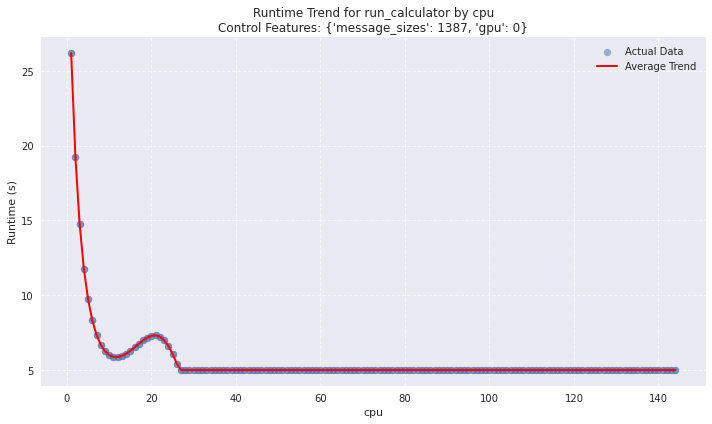

In [11]:
def visualize_runtime_trends(data, method: str, feature: str = 'message_sizes',
                        control_features: Dict[str, Any] = None,
                        show_scatter: bool = True):
    """
    使用matplotlib生成任务运行时间随特定特征变化的可视化图表
    
    Args:
        method: 要可视化的方法名
        feature: 要观察的特征名称 ('message_sizes', 'cpu', 'gpu')
        control_features: 其他特征的固定值，例如 {'cpu': 4, 'gpu': 1}
        show_scatter: 是否显示散点图
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    plt.style.use('seaborn')
    data = data[method]
    
    if len(data) == 0:
        logger.warning(f"No data available for method {method}")
        return
        
    # 准备数据
    valid_mask = ~np.isnan(data['time_running'])
    valid_data = data[valid_mask]
    
    # 如果指定了控制特征，进一步过滤数据
    if control_features:
        for feat, value in control_features.items():
            valid_data = valid_data[valid_data[feat] == value]
            
    if len(valid_data) == 0:
        logger.warning("No valid data after filtering")
        return
            
    # 创建图表
    plt.figure(figsize=(10, 6))
    
    # 绘制散点图
    if show_scatter:
        plt.scatter(valid_data[feature], valid_data['time_running'], 
                alpha=0.5, label='Actual Data')
    
    # 对特征值排序并计算平均运行时间趋势线
    unique_features = np.unique(valid_data[feature])
    avg_times = []
    for feat_value in unique_features:
        mask = valid_data[feature] == feat_value
        avg_time = np.mean(valid_data['time_running'][mask])
        avg_times.append(avg_time)
    
    # 绘制趋势线
    plt.plot(unique_features, avg_times, 'r-', linewidth=2, label='Average Trend')
    
    # 设置图表标题和标签
    title = f'Runtime Trend for {method} by {feature}'
    if control_features:
        title += f'\nControl Features: {control_features}'
    plt.title(title)
    plt.xlabel(feature)
    plt.ylabel('Runtime (s)')
    
    # 添加图例
    plt.legend()
    
    # 添加网格
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 优化布局
    plt.tight_layout()
    
    # 显示图表
    plt.show()
visualize_runtime_trends(data = tq.smart_sch.sch_data.Task_time_predictor.time_running_db, method = "run_calculator", feature="cpu", control_features={"message_sizes":1387, "gpu":0})

In [12]:
## running 
print(tq._hist_data)
print(tq.smart_sch.sch_data.avail_task.get_all())
# tq.evosch.population = tq.evosch.generate_population(100)
# predifine_ind = tq.evosch.population[-1]
# print(predifine_ind.task_allocation)
# measure time consume
profiler = cProfile.Profile()
profiler.enable()

start_time = time.time() 
tq.best_allocation = tq.smart_sch.run_sch(method="ga")

print(tq.best_allocation)
# print(tq.smart_sch.best_result)
# print(tq.smart_sch.sch_data.historical_task_data.historical_data['evaluate'])
end_time = time.time()
running_time = end_time - start_time

profiler.disable()
stats = pstats.Stats(profiler).sort_stats('cumulative')
stats.print_stats()

print(f"GA running_time:{running_time}")
print(f"predict completion time:{tq.smart_sch.best_result.score}")

for task in tq.best_allocation:
    print(f"name:{task['name']}, resource:{task['resources']}, running_time:{task['total_runtime']}")


profiler.dump_stats("profile_data.prof")

{'run_calculator': ['a357e08c-0156-4f17-a634-cd30495021d1', 'a5de0c3a-6c7b-4ef7-a040-ecd03beb375d', 'ae587d8e-8071-4319-b9ef-86fea7688a97', '33e68173-24fd-4448-a809-1b8fac388b55', '0f97217a-d047-449d-a682-20c1fe3c04e8', '0c0a7e3b-5a9b-4b40-96bf-40c3db5a37ff', '91884136-b47f-4136-9c24-f196d0bbfc0c', '2a0889af-510e-41f3-a6f0-f9457c45bd23', 'd68551dd-65ba-4fdd-b7e9-5d01edbe65a3', '1e4be933-8353-466b-9274-5feaf387b3e0', 'aa687c3f-780a-436a-9f4d-eafdca9d04bf', 'f9124c3f-67f8-4a2b-83ae-8fca8002ddc6', '9d0e76dc-f9e9-4fb8-bc6c-f5b5a783b000', 'a8957f13-17d4-4fdd-92d4-872736ff6db6', '89439110-d1f1-49a0-9b39-3c6ff85fc9c7', 'f5905ef9-1d0a-43e1-b11e-358d32a0ce74', 'cd66fca9-60a1-4e84-a166-7480b19bf985', 'd56fbae6-1d8f-4ba6-87c8-819a7de84ff3', '3c199164-7a2c-4b3b-8870-a090d16a230a', 'cd2a4d1e-8877-42b0-ab22-2abe45482dc0'], 'evaluate': [], 'train': ['9c7a8a53-27d0-4222-9998-f3ac8466ddba', '2d72ae3c-d5fe-42b8-9953-3ccff732c32e', '2be71694-af42-485f-a854-c5a06d845656'], 'run_sampling': []}


INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU


AttributeError: 'SmartScheduler' object has no attribute 'scheduler_timer'

In [ ]:
# real and predict diff
def get_features_from_his_json(his_json: Union[str, list[str]]):
    features = [
                "task_id",
                "method",
                "message_sizes.inputs",
                "resources.cpu",
                "resources.gpu",
                "time_running",
                "resources.node",
            ]
    data = []
    for path in his_json:
        with open(path, 'r') as f:
            for line in f:
                json_line = json.loads(line)
                feature_values = {}
                for feature in features:
                    value = json_line
                    for key in feature.split('.'):
                        value = value.get(key)
                    if feature == 'resources.gpu':
                        value = (
                            len(value) if isinstance(value, list) else value
                        )
                        # if value is None:
                        #     break
                    feature_values[feature] = value
                data.append(feature_values)
    return data

data = Path("/home/yxx/project/colmena/multisite_/finetuning-surrogates/analysis/test_result/simulation-results.json")
data_list = get_features_from_his_json([data])
print(data_list)
for data in data_list:
    
    predict_time = data['time_running']
    real_time = predictor._predict_single(data['method'], (data['message_sizes.inputs'], data['resources.cpu'], data['resources.gpu']))
    diff = predict_time - real_time
    if abs(diff)/predict_time > 0.2:
        print(data)
        print(predict_time, real_time, diff)

[{'task_id': '7655b094-8b49-43a6-a50d-1b40d99e20f7', 'method': 'run_calculator', 'message_sizes.inputs': 1387, 'resources.cpu': 1, 'resources.gpu': 0, 'time_running': 26.111163463443518, 'resources.node': 'a02u06b'}, {'task_id': 'e50d9e0d-7355-4d13-86ed-76a24ea4789d', 'method': 'run_calculator', 'message_sizes.inputs': 1387, 'resources.cpu': 1, 'resources.gpu': 0, 'time_running': 27.25548468157649, 'resources.node': 'a01u12b'}, {'task_id': '4bb3cb12-109c-4eb8-9415-22869dea5505', 'method': 'run_calculator', 'message_sizes.inputs': 5277, 'resources.cpu': 5, 'resources.gpu': 0, 'time_running': 156.93054643273354, 'resources.node': 'a01u12b'}, {'task_id': '2f11ed3f-3118-4413-bedd-b6f881374005', 'method': 'run_calculator', 'message_sizes.inputs': 3549, 'resources.cpu': 1, 'resources.gpu': 0, 'time_running': 182.75426710769534, 'resources.node': 'a01u12b'}, {'task_id': 'aee5d15b-96cd-4b46-b32d-9c7a662ced47', 'method': 'run_calculator', 'message_sizes.inputs': 7005, 'resources.cpu': 10, 'reso

In [ ]:
import json
from pathlib import Path
from typing import Union
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec  # 添加这行
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy import stats

queue_v3_64 = """
a01u01a            closed          -     24     24     24      0      0      0
a01u01b            closed          -     24     24     24      0      0      0
a01u02a            ok              -     24      0      0      0      0      0
a01u02b            closed          -     24     24     24      0      0      0
a01u03a            closed          -     24     24     24      0      0      0
a01u03b            closed          -     24     24     24      0      0      0
a01u04b            closed          -     24     24     24      0      0      0
a01u05a            closed          -     24     24     24      0      0      0
a01u05b            closed          -     24     24     24      0      0      0
a01u06a            closed          -     24     24     24      0      0      0
a01u06b            closed          -     24     24     24      0      0      0
a01u07a            closed          -     24     24     24      0      0      0
a01u07b            closed          -     24     24     24      0      0      0
a01u08a            closed          -     24     24     24      0      0      0
a01u08b            closed          -     24     24     24      0      0      0
a01u09a            ok              -     24      0      0      0      0      0
a01u09b            ok              -     24      0      0      0      0      0
a01u10a            closed          -     24     24     24      0      0      0
a01u10b            closed          -     24     24     24      0      0      0
a01u11a            ok              -     24      0      0      0      0      0
a01u11b            closed          -     24     24     24      0      0      0
a01u12a            ok              -     24      0      0      0      0      0
a01u12b            ok              -     24      0      0      0      0      0
a01u13a            closed          -     24     24     24      0      0      0
a01u13b            closed          -     24     24     24      0      0      0
a01u14a            closed          -     24     24     24      0      0      0
a01u14b            ok              -     24      0      0      0      0      0
a01u15a            ok              -     24      0      0      0      0      0
a01u15b            closed          -     24     24     24      0      0      0
a01u16a            ok              -     24      0      0      0      0      0
a01u16b            ok              -     24      0      0      0      0      0
a01u17a            ok              -     24      0      0      0      0      0
a01u17b            ok              -     24      0      0      0      0      0
a01u18a            closed          -     24     24     24      0      0      0
a01u18b            ok              -     24      0      0      0      0      0
a01u19a            ok              -     24      0      0      0      0      0
a01u19b            closed          -     24     24     24      0      0      0
a01u20b            closed          -     24     24     24      0      0      0
a02u01a            ok              -     24      0      0      0      0      0
a02u01b            ok              -     24      0      0      0      0      0
a02u02a            closed          -     24     24     24      0      0      0
a02u02b            closed          -     24     24     24      0      0      0
a02u03a            ok              -     24      0      0      0      0      0
a02u03b            closed          -     24     24     24      0      0      0
a02u04a            ok              -     24      0      0      0      0      0
a02u04b            closed          -     24     24     24      0      0      0
a02u05a            ok              -     24      0      0      0      0      0
a02u05b            ok              -     24      0      0      0      0      0
a02u06a            ok              -     24      0      0      0      0      0
a02u06b            ok              -     24      0      0      0      0      0
a02u07a            ok              -     24      0      0      0      0      0
a02u07b            ok              -     24      0      0      0      0      0
a02u08a            ok              -     24      0      0      0      0      0
a02u08b            ok              -     24     12     12      0      0      0
a02u09a            ok              -     24      0      0      0      0      0
a02u09b            ok              -     24      0      0      0      0      0
a02u10a            closed          -     24     24     24      0      0      0
a02u10b            ok              -     24      0      0      0      0      0
a02u11a            closed          -     24     24     24      0      0      0
a02u11b            closed          -     24     24     24      0      0      0
a02u12a            ok              -     24      0      0      0      0      0
a02u12b            closed          -     24     24     24      0      0      0
a02u13a            closed          -     24     24     24      0      0      0
a02u13b            ok              -     24      0      0      0      0      0
a02u14a            closed          -     24     24     24      0      0      0
a02u14b            ok              -     24      0      0      0      0      0
a02u15a            ok              -     24      0      0      0      0      0
a02u15b            closed          -     24     24     24      0      0      0
a02u16a            ok              -     24      0      0      0      0      0
a02u16b            ok              -     24      0      0      0      0      0
a02u17a            ok              -     24      0      0      0      0      0
a02u17b            ok              -     24      0      0      0      0      0
a02u18a            ok              -     24      0      0      0      0      0
a02u18b            ok              -     24      0      0      0      0      0
a02u19a            ok              -     24      0      0      0      0      0
a02u19b            ok              -     24      0      0      0      0      0
a02u20a            ok              -     24      0      0      0      0      0
a02u20b            ok              -     24      0      0      0      0      0
a03u04a            closed          -     24     24     24      0      0      0
a03u04b            closed          -     24     24     24      0      0      0
a03u05a            closed          -     24     24     24      0      0      0
a03u05b            ok              -     24      0      0      0      0      0
a03u06a            closed          -     24     24     24      0      0      0
a03u06b            ok              -     24      0      0      0      0      0
a03u07a            ok              -     24      0      0      0      0      0
a03u07b            closed          -     24     24     24      0      0      0
a03u08a            closed          -     24     24     24      0      0      0
a03u08b            closed          -     24     24     24      0      0      0
a03u09a            ok              -     24      0      0      0      0      0
a03u09b            ok              -     24      0      0      0      0      0
a03u10a            ok              -     24      0      0      0      0      0
a03u10b            closed          -     24     24     24      0      0      0
a03u11a            closed          -     24     24     24      0      0      0
a03u11b            closed          -     24     24     24      0      0      0
a03u12a            closed          -     24     24     24      0      0      0
a03u12b            closed          -     24     24     24      0      0      0
a03u13a            closed          -     24     24     24      0      0      0
a03u13b            ok              -     24      0      0      0      0      0
a03u14a            closed          -     24     24     24      0      0      0
a03u14b            ok              -     24      0      0      0      0      0
a03u15a            ok              -     24      0      0      0      0      0
a03u15b            closed          -     24     24     24      0      0      0
a03u16a            ok              -     24      0      0      0      0      0
a03u16b            ok              -     24      0      0      0      0      0
a03u17a            closed          -     24     24     24      0      0      0
a03u17b            ok              -     24      0      0      0      0      0
a03u18a            ok              -     24      0      0      0      0      0
a03u18b            ok              -     24      0      0      0      0      0
a03u19a            closed          -     24     24     24      0      0      0
a03u19b            ok              -     24      0      0      0      0      0
a03u21a            ok              -     24      0      0      0      0      0
a03u21b            closed          -     24     24     24      0      0      0
a03u22a            closed          -     24     24     24      0      0      0
a03u22b            ok              -     24      0      0      0      0      0
a03u23a            ok              -     24      0      0      0      0      0
a03u23b            ok              -     24      0      0      0      0      0
a06u04a            closed          -     24     24     24      0      0      0
a06u04b            ok              -     24      0      0      0      0      0
a06u05a            ok              -     24      0      0      0      0      0
a06u05b            closed          -     24     24     24      0      0      0
a06u06a            ok              -     24      0      0      0      0      0
a06u06b            ok              -     24      0      0      0      0      0
a06u07a            ok              -     24      0      0      0      0      0
a06u07b            ok              -     24      0      0      0      0      0
a06u08a            closed          -     24     24     24      0      0      0
a06u08b            closed          -     24     24     24      0      0      0
a06u09a            closed          -     24     24     24      0      0      0
a06u09b            closed          -     24     24     24      0      0      0
a06u10a            closed          -     24     24     24      0      0      0
a06u10b            ok              -     24      0      0      0      0      0
a06u11a            ok              -     24      0      0      0      0      0
a06u11b            closed          -     24     24     24      0      0      0
a06u12a            ok              -     24      0      0      0      0      0
a06u12b            ok              -     24      0      0      0      0      0
a06u13a            ok              -     24      0      0      0      0      0
a06u13b            closed          -     24     24     24      0      0      0
a06u14a            ok              -     24      0      0      0      0      0
a06u14b            ok              -     24      0      0      0      0      0
a06u15a            ok              -     24      0      0      0      0      0
a06u15b            ok              -     24      0      0      0      0      0
a06u16a            ok              -     24      1      1      0      0      0
a06u16b            closed          -     24     24     24      0      0      0
a06u17a            ok              -     24      0      0      0      0      0
a06u17b            closed          -     24     24     24      0      0      0
a06u18a            ok              -     24      0      0      0      0      0
a06u18b            ok              -     24      0      0      0      0      0
a06u19a            closed          -     24     24     24      0      0      0
a06u19b            closed          -     24     24     24      0      0      0
a06u20a            ok              -     24      0      0      0      0      0
a06u20b            ok              -     24      0      0      0      0      0
a06u21a            closed          -     24     24     24      0      0      0
a06u21b            ok              -     24      0      0      0      0      0
a06u22a            ok              -     24      0      0      0      0      0
a06u22b            ok              -     24      0      0      0      0      0
a06u23a            closed          -     24     24     24      0      0      0
a06u23b            ok              -     24      0      0      0      0      0
a07u01a            closed          -     24     24     24      0      0      0
a07u01b            closed          -     24     24     24      0      0      0
a07u02a            ok              -     24      0      0      0      0      0
a07u02b            closed          -     24     24     24      0      0      0
a07u03a            ok              -     24      0      0      0      0      0
a07u03b            ok              -     24      0      0      0      0      0
a07u04a            ok              -     24      0      0      0      0      0
a07u04b            ok              -     24      0      0      0      0      0
a07u05a            closed          -     24     24     24      0      0      0
a07u05b            ok              -     24      0      0      0      0      0
a07u06a            ok              -     24      0      0      0      0      0
a07u06b            ok              -     24      0      0      0      0      0
a07u07a            ok              -     24      0      0      0      0      0
a07u07b            ok              -     24      0      0      0      0      0
a07u08a            ok              -     24      0      0      0      0      0
a07u08b            closed          -     24     24     24      0      0      0
a07u09a            ok              -     24      0      0      0      0      0
a07u09b            ok              -     24      0      0      0      0      0
a07u10a            closed          -     24     24     24      0      0      0
a07u10b            closed          -     24     24     24      0      0      0
a07u11a            closed          -     24     24     24      0      0      0
a07u11b            ok              -     24      0      0      0      0      0
a07u12a            ok              -     24      0      0      0      0      0
a07u12b            ok              -     24      0      0      0      0      0
a07u13a            ok              -     24      0      0      0      0      0
a07u13b            closed          -     24     24     24      0      0      0
a07u14a            ok              -     24      0      0      0      0      0
a07u14b            ok              -     24      0      0      0      0      0
a07u15a            ok              -     24      0      0      0      0      0
a07u15b            ok              -     24      0      0      0      0      0
a07u16a            ok              -     24      0      0      0      0      0
a07u16b            ok              -     24      0      0      0      0      0
a07u17a            closed          -     24     24     24      0      0      0
a07u17b            ok              -     24      0      0      0      0      0
a07u18a            closed          -     24     24     24      0      0      0
a07u18b            ok              -     24      0      0      0      0      0
a07u19a            ok              -     24      0      0      0      0      0
a07u19b            ok              -     24      0      0      0      0      0
a07u20a            ok              -     24      0      0      0      0      0
a07u20b            ok              -     24      0      0      0      0      0
a08u06a            closed          -     24     24     24      0      0      0
a08u06b            closed          -     24     24     24      0      0      0
a08u07a            ok              -     24      0      0      0      0      0
a08u07b            closed          -     24     24     24      0      0      0
a08u08a            ok              -     24      0      0      0      0      0
a08u08b            closed          -     24     24     24      0      0      0
a08u09a            ok              -     24      0      0      0      0      0
a08u09b            closed          -     24     24     24      0      0      0
a08u10a            closed          -     24     24     24      0      0      0
a08u10b            closed          -     24     24     24      0      0      0
a08u11a            closed          -     24     24     24      0      0      0
a08u11b            closed          -     24     24     24      0      0      0
a08u12a            closed          -     24     24     24      0      0      0
a08u12b            closed          -     24     24     24      0      0      0
a08u13a            closed          -     24     24     24      0      0      0
a08u13b            closed          -     24     24     24      0      0      0
a08u14b            closed          -     24     24     24      0      0      0
a08u15a            ok              -     24      0      0      0      0      0
a08u15b            ok              -     24      0      0      0      0      0
a08u16a            ok              -     24      0      0      0      0      0
a08u16b            ok              -     24      0      0      0      0      0
a08u17a            ok              -     24      0      0      0      0      0
a08u17b            ok              -     24      0      0      0      0      0
a08u18a            closed          -     24     24     24      0      0      0
a08u18b            ok              -     24      0      0      0      0      0
a08u19a            closed          -     24     24     24      0      0      0
a08u19b            ok              -     24      0      0      0      0      0
a08u20a            closed          -     24     24     24      0      0      0
a08u20b            ok              -     24      0      0      0      0      0
"""

queue_2a100_40 = """
b05u37g            ok              -     40      1      1      0      0      0
"""
def map_nodes_to_queue(output: str, queue_name: str):
    """
    Parse the bhosts output and map all nodes to the specified queue.
    
    Args:
    - output (str): The bhosts output as a string.
    - queue_name (str): The name of the queue to which all nodes will be mapped.
    
    Returns:
    - dict: A dictionary mapping nodes to the specified queue.
    """
    # Initialize an empty dictionary for the mapping
    node_to_queue = {}
    
    # Split the output into lines
    lines = output.splitlines()
    
    # Skip the header lines and start processing the nodes
    for line in lines:
        # Skip empty lines and header lines
        if not line.strip() or line.startswith("HOST_NAME") or line.startswith("->"):
            continue
        
        # Split the line into columns (assuming columns are separated by whitespace)
        columns = line.split()
        
        if len(columns) < 2:
            continue  # Skip malformed lines
        
        # Extract the node name
        node_name = columns[0]
        
        # Map the node to the specified queue
        node_to_queue[node_name] = queue_name
    
    return node_to_queue
map_dict = {}
map_dict.update(map_nodes_to_queue(queue_v3_64, 'v3-64'))
map_dict.update(map_nodes_to_queue(queue_2a100_40, '2a100-40'))
print(map_dict)



def get_features_from_his_json(his_json: Union[str, list[str]]):
    features = [
        "task_id",
        "method",
        "message_sizes.inputs",
        "resources.cpu",
        "resources.gpu",
        "time_running",
        "resources.node" 
    ]
    data = []
    for path in his_json:
        with open(path, 'r') as f:
            for line in f:
                json_line = json.loads(line)
                feature_values = {}
                for feature in features:
                    value = json_line
                    for key in feature.split('.'):
                        value = value.get(key)
                    if feature == 'resources.gpu':
                        value = len(value) if isinstance(value, list) else value
                    feature_values[feature] = value
                # 添加队列信息
                # feature_values['queue'] = get_queue_from_hostname(feature_values.get('resources.node', ''))
                feature_values['queue'] = map_dict.get(feature_values.get('resources.node', ''))
                data.append(feature_values)
    return data

# 分析不同队列的时间差异
def analyze_queue_time_diff(data_list):
    queue_diffs = defaultdict(list)
    
    for data in data_list:
        queue = data['queue']
        predict_time = data['time_running']
        real_time = predictor._predict_single(data['method'], 
                                           (data['message_sizes.inputs'], 
                                            data['resources.cpu'], 
                                            data['resources.gpu']))
        time_diff = predict_time - real_time
        queue_diffs[queue].append(time_diff)
    
    # 计算每个队列的统计信息
    queue_stats = {}
    for queue, diffs in queue_diffs.items():
        avg_diff = sum(diffs) / len(diffs)
        max_diff = max(diffs)
        min_diff = min(diffs)
        abs_avg_diff = sum(abs(d) for d in diffs) / len(diffs)
        
        queue_stats[queue] = {
            'count': len(diffs),
            'avg_diff': avg_diff,
            'max_diff': max_diff,
            'min_diff': min_diff,
            'abs_avg_diff': abs_avg_diff
        }
    
    return queue_stats

# 加载数据并分析
data = Path("/home/yxx/project/colmena/multisite_/finetuning-surrogates/analysis/test_result/simulation-results.json")
data_list = get_features_from_his_json([data])
queue_stats = analyze_queue_time_diff(data_list)

# 打印分析结果
for queue, stats in queue_stats.items():
    print(f"\nQueue: {queue}")
    print(f"Number of tasks: {stats['count']}")
    print(f"Average time difference: {stats['avg_diff']:.2f} seconds")
    print(f"Maximum time difference: {stats['max_diff']:.2f} seconds")
    print(f"Minimum time difference: {stats['min_diff']:.2f} seconds")
    print(f"Average absolute difference: {stats['abs_avg_diff']:.2f} seconds")

{'a01u01a': 'v3-64', 'a01u01b': 'v3-64', 'a01u02a': 'v3-64', 'a01u02b': 'v3-64', 'a01u03a': 'v3-64', 'a01u03b': 'v3-64', 'a01u04b': 'v3-64', 'a01u05a': 'v3-64', 'a01u05b': 'v3-64', 'a01u06a': 'v3-64', 'a01u06b': 'v3-64', 'a01u07a': 'v3-64', 'a01u07b': 'v3-64', 'a01u08a': 'v3-64', 'a01u08b': 'v3-64', 'a01u09a': 'v3-64', 'a01u09b': 'v3-64', 'a01u10a': 'v3-64', 'a01u10b': 'v3-64', 'a01u11a': 'v3-64', 'a01u11b': 'v3-64', 'a01u12a': 'v3-64', 'a01u12b': 'v3-64', 'a01u13a': 'v3-64', 'a01u13b': 'v3-64', 'a01u14a': 'v3-64', 'a01u14b': 'v3-64', 'a01u15a': 'v3-64', 'a01u15b': 'v3-64', 'a01u16a': 'v3-64', 'a01u16b': 'v3-64', 'a01u17a': 'v3-64', 'a01u17b': 'v3-64', 'a01u18a': 'v3-64', 'a01u18b': 'v3-64', 'a01u19a': 'v3-64', 'a01u19b': 'v3-64', 'a01u20b': 'v3-64', 'a02u01a': 'v3-64', 'a02u01b': 'v3-64', 'a02u02a': 'v3-64', 'a02u02b': 'v3-64', 'a02u03a': 'v3-64', 'a02u03b': 'v3-64', 'a02u04a': 'v3-64', 'a02u04b': 'v3-64', 'a02u05a': 'v3-64', 'a02u05b': 'v3-64', 'a02u06a': 'v3-64', 'a02u06b': 'v3-64',

In [ ]:
import json
from pathlib import Path
from typing import Union
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np



def analyze_time_differences(data_list):
    """分析时间差异并计算统计信息"""
    diffs = []
    percentages = []
    
    for data in data_list:
        predict_time = data['time_running']
        real_time = predictor._predict_single(data['method'], 
                                           (data['message_sizes.inputs'], 
                                            data['resources.cpu'], 
                                            data['resources.gpu']))
        diff = predict_time - real_time
        percentage = (diff / real_time) * 100 if real_time != 0 else 0
        
        diffs.append({
            'task_id': data['task_id'],
            'diff': diff,
            'percentage': percentage,
            'input_size': data['message_sizes.inputs'],
            'cpu': data['resources.cpu']
        })
    
    return diffs

def visualize_differences(diffs):
    """可视化时间差异"""
    plt.figure(figsize=(15, 10))
    
    # 绘制差值柱状图
    task_indices = range(len(diffs))
    differences = [d['diff'] for d in diffs]
    percentages = [d['percentage'] for d in diffs]
    
    # 创建主图和共享x轴的副图
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios':[2, 1]})
    
    # 绘制时间差异
    bars = ax1.bar(task_indices, differences)
    ax1.set_ylabel('Time Difference (seconds)')
    ax1.set_title('Time Prediction Differences by Task')
    
    # 添加平均线
    avg_diff = np.mean(differences)
    ax1.axhline(y=avg_diff, color='r', linestyle='--', 
                label=f'Average Diff: {avg_diff:.2f}s ({np.mean(percentages):.1f}%)')
    
    # 绘制百分比差异
    ax2.plot(task_indices, percentages, color='green', label='Percentage Difference')
    ax2.set_ylabel('Percentage Difference (%)')
    ax2.set_xlabel('Task Index')
    
    # 添加网格
    ax1.grid(True, alpha=0.3)
    ax2.grid(True, alpha=0.3)
    
    # 添加图例
    ax1.legend()
    ax2.legend()
    
    # 使柱状图的颜色根据差值大小变化
    normalize = plt.Normalize(min(differences), max(differences))
    colors = plt.cm.RdYlBu(normalize(differences))
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    # 添加统计信息文本框
    stats_text = (f'Average Diff: {avg_diff:.2f}s\n'
                 f'Average Percentage: {np.mean(percentages):.1f}%\n'
                 f'Max Diff: {max(differences):.2f}s\n'
                 f'Min Diff: {min(differences):.2f}s\n'
                 f'Std Dev: {np.std(differences):.2f}s')
    
    plt.figtext(0.95, 0.95, stats_text,
                bbox=dict(facecolor='white', alpha=0.8),
                verticalalignment='top',
                horizontalalignment='right')
    
    plt.tight_layout()
    plt.show()

    # 打印详细统计信息
    print("\nDetailed Statistics:")
    print(f"Average Difference: {avg_diff:.2f} seconds ({np.mean(percentages):.1f}%)")
    print(f"Median Difference: {np.median(differences):.2f} seconds")
    print(f"Standard Deviation: {np.std(differences):.2f} seconds")
    print(f"Maximum Difference: {max(differences):.2f} seconds ({max(percentages):.1f}%)")
    print(f"Minimum Difference: {min(differences):.2f} seconds ({min(percentages):.1f}%)")
    
    # 分析输入大小和CPU核心数的相关性
    input_sizes = [d['input_size'] for d in diffs]
    cpus = [d['cpu'] for d in diffs]
    
    print("\nCorrelation Analysis:")
    print(f"Correlation with input size: {np.corrcoef(input_sizes, differences)[0,1]:.3f}")
    print(f"Correlation with CPU cores: {np.corrcoef(cpus, differences)[0,1]:.3f}")

# 主执行代码
data = Path("/home/yxx/project/colmena/multisite_/finetuning-surrogates/analysis/test_result/simulation-results.json")
data_list = get_features_from_his_json([data])
diffs = analyze_time_differences(data_list)
visualize_differences(diffs)

NameError: name 'get_features_from_his_json' is not defined

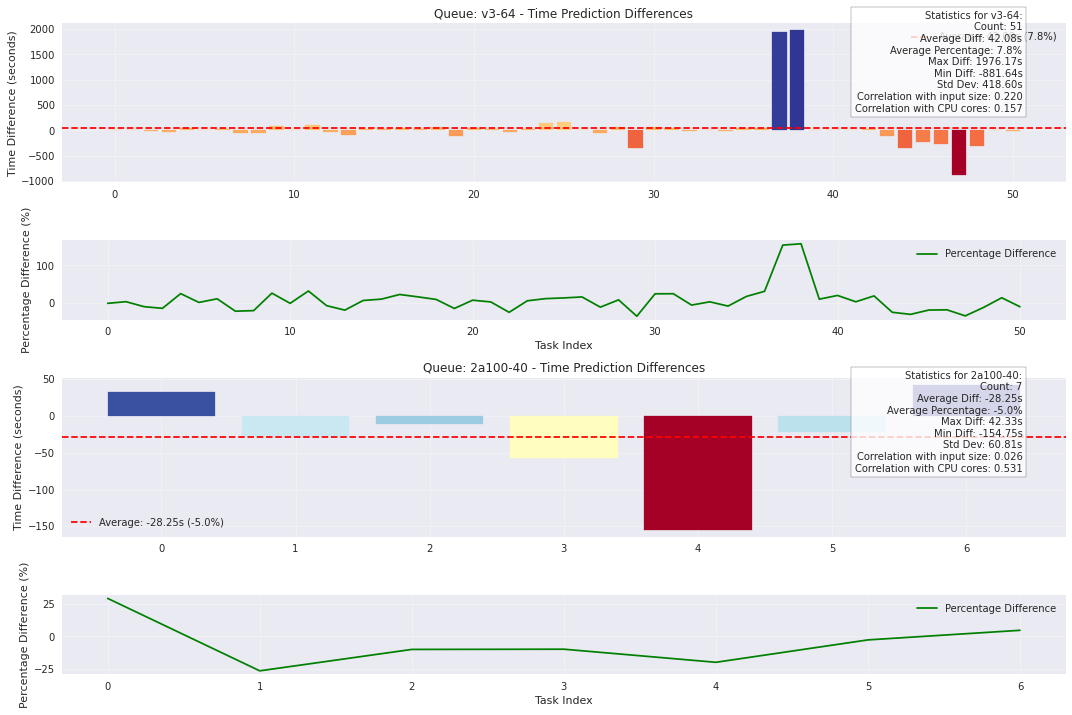


Queue Comparison Statistics:

v3-64 Queue:
Number of tasks: 51
Average Difference: 42.08 seconds (7.8%)
Median Difference: 7.34 seconds
Standard Deviation: 418.60 seconds
Maximum Difference: 1976.17 seconds (157.5%)
Minimum Difference: -881.64 seconds (-34.4%)

2a100-40 Queue:
Number of tasks: 7
Average Difference: -28.25 seconds (-5.0%)
Median Difference: -22.39 seconds
Standard Deviation: 60.81 seconds
Maximum Difference: 42.33 seconds (28.9%)
Minimum Difference: -154.75 seconds (-26.2%)


In [ ]:
def analyze_time_differences(data_list):
    """分析时间差异并计算统计信息"""
    diffs = []
    
    for data in data_list:
        predict_time = data['time_running']
        real_time = predictor._predict_single(data['method'], 
                                           (data['message_sizes.inputs'], 
                                            data['resources.cpu'], 
                                            data['resources.gpu']))
        diff = predict_time - real_time
        percentage = (diff / real_time) * 100 if real_time != 0 else 0
        
        diffs.append({
            'task_id': data['task_id'],
            'diff': diff,
            'percentage': percentage,
            'input_size': data['message_sizes.inputs'],
            'cpu': data['resources.cpu'],
            'queue': data['queue']  # 添加队列信息
        })
    
    return diffs

def visualize_differences_by_queue(diffs):
    """按队列分组可视化时间差异"""
    # 按队列分组数据
    queue_data = defaultdict(list)
    for diff in diffs:
        queue_data[diff['queue']].append(diff)
    
    # 创建子图
    n_queues = len(queue_data)
    fig = plt.figure(figsize=(15, 5 * n_queues))
    gs = gridspec.GridSpec(n_queues * 2, 1, height_ratios=[2, 1] * n_queues)
    
    # 为每个队列创建图表
    for idx, (queue, queue_diffs) in enumerate(queue_data.items()):
        # 提取数据
        differences = [d['diff'] for d in queue_diffs]
        percentages = [d['percentage'] for d in queue_diffs]
        task_indices = range(len(differences))
        
        # 创建差值图
        ax1 = plt.subplot(gs[idx * 2])
        bars = ax1.bar(task_indices, differences)
        
        # 计算统计数据
        avg_diff = np.mean(differences)
        avg_percent = np.mean(percentages)
        
        # 添加平均线
        ax1.axhline(y=avg_diff, color='r', linestyle='--', 
                    label=f'Average: {avg_diff:.2f}s ({avg_percent:.1f}%)')
        
        # 设置标题和标签
        ax1.set_title(f'Queue: {queue} - Time Prediction Differences')
        ax1.set_ylabel('Time Difference (seconds)')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # 使用颜色映射
        normalize = plt.Normalize(min(differences), max(differences))
        colors = plt.cm.RdYlBu(normalize(differences))
        for bar, color in zip(bars, colors):
            bar.set_color(color)
            
        # 创建百分比图
        ax2 = plt.subplot(gs[idx * 2 + 1])
        ax2.plot(task_indices, percentages, color='green', label='Percentage Difference')
        ax2.set_ylabel('Percentage Difference (%)')
        ax2.set_xlabel('Task Index')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        # 添加统计信息文本框
        stats_text = (
            f'Statistics for {queue}:\n'
            f'Count: {len(differences)}\n'
            f'Average Diff: {avg_diff:.2f}s\n'
            f'Average Percentage: {avg_percent:.1f}%\n'
            f'Max Diff: {max(differences):.2f}s\n'
            f'Min Diff: {min(differences):.2f}s\n'
            f'Std Dev: {np.std(differences):.2f}s\n'
            f'Correlation with input size: {np.corrcoef([d["input_size"] for d in queue_diffs], differences)[0,1]:.3f}\n'
            f'Correlation with CPU cores: {np.corrcoef([d["cpu"] for d in queue_diffs], differences)[0,1]:.3f}'
        )
        
        plt.figtext(0.95, 0.98 - (idx * 0.5), stats_text,
                    bbox=dict(facecolor='white', alpha=0.8),
                    verticalalignment='top',
                    horizontalalignment='right')
    
    plt.tight_layout()
    plt.show()
    
    # 打印队列间的比较统计
    print("\nQueue Comparison Statistics:")
    for queue, queue_diffs in queue_data.items():
        differences = [d['diff'] for d in queue_diffs]
        percentages = [d['percentage'] for d in queue_diffs]
        
        print(f"\n{queue} Queue:")
        print(f"Number of tasks: {len(differences)}")
        print(f"Average Difference: {np.mean(differences):.2f} seconds ({np.mean(percentages):.1f}%)")
        print(f"Median Difference: {np.median(differences):.2f} seconds")
        print(f"Standard Deviation: {np.std(differences):.2f} seconds")
        print(f"Maximum Difference: {max(differences):.2f} seconds ({max(percentages):.1f}%)")
        print(f"Minimum Difference: {min(differences):.2f} seconds ({min(percentages):.1f}%)")

# 主执行代码
data = Path("/home/yxx/project/colmena/multisite_/finetuning-surrogates/analysis/test_result/simulation-results.json")
data_list = get_features_from_his_json([data])
diffs = analyze_time_differences(data_list)
visualize_differences_by_queue(diffs)

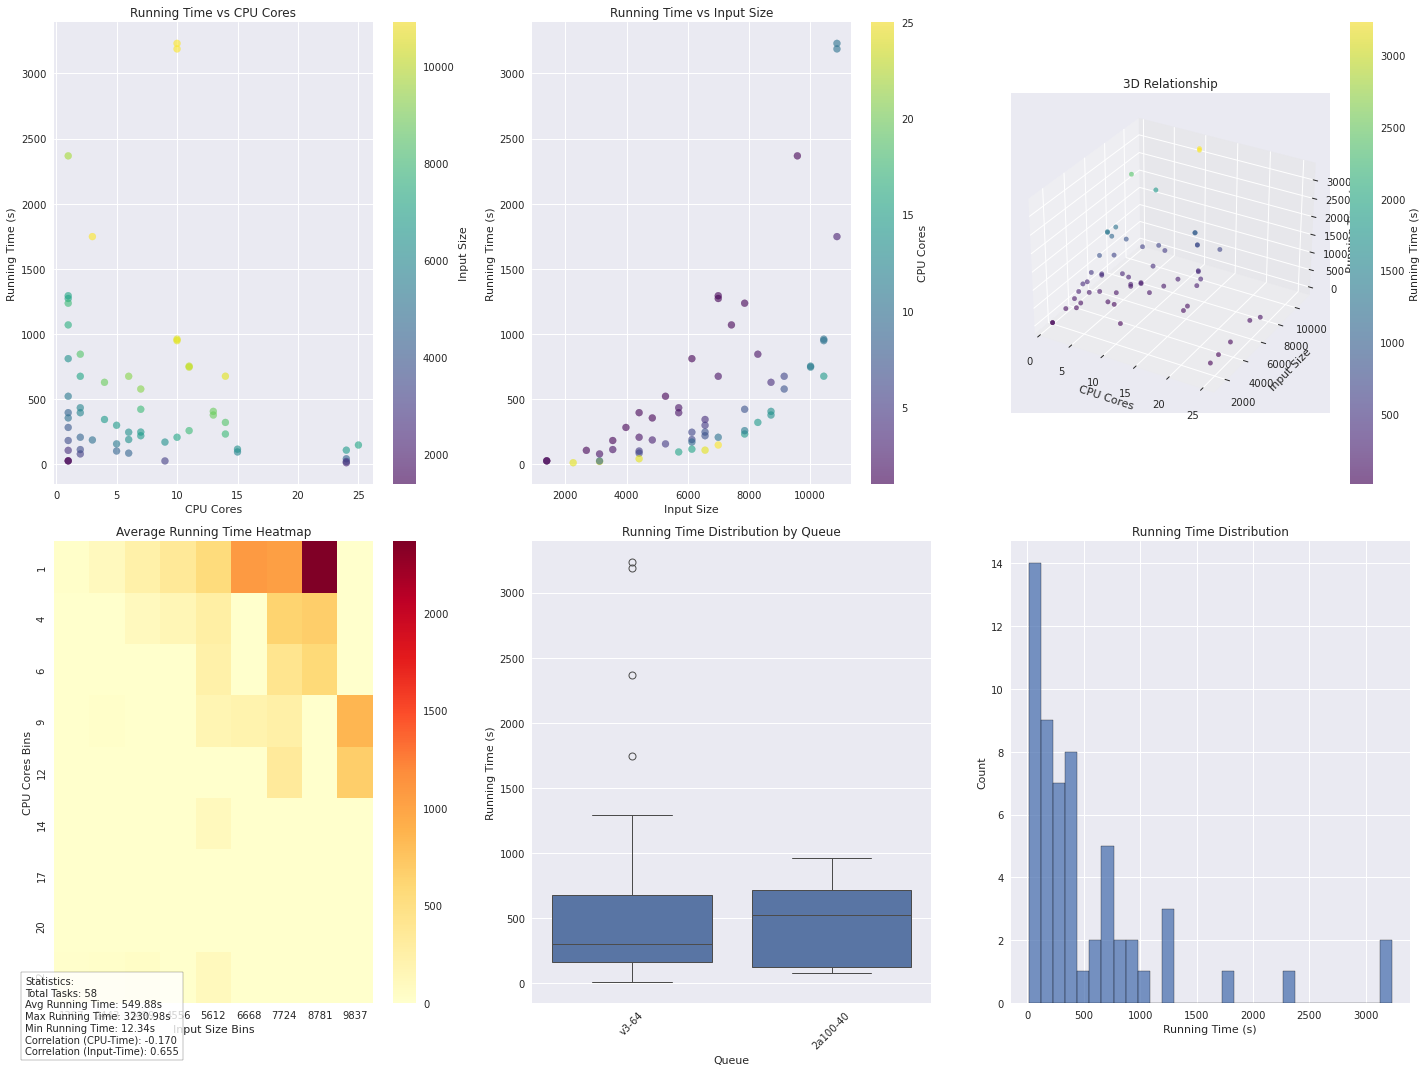


Detailed Statistics by Queue:

Queue: v3-64
Number of tasks: 51
Average running time: 561.55s
Median running time: 299.76s
Standard deviation: 717.10s
Min running time: 12.34s
Max running time: 3230.98s
Correlation with CPU: -0.172
Correlation with input size: 0.659

Queue: 2a100-40
Number of tasks: 7
Average running time: 464.85s
Median running time: 522.37s
Standard deviation: 359.68s
Min running time: 79.80s
Max running time: 960.67s
Correlation with CPU: -0.242
Correlation with input size: 0.740


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import numpy as np
from scipy import stats

def visualize_resource_time_relationship(data_list):
    """可视化任务运行时间与资源使用的关系"""
    
    # 提取数据
    cpu_resources = np.array([d['resources.cpu'] for d in data_list])
    input_sizes = np.array([d['message_sizes.inputs'] for d in data_list])
    running_times = np.array([d['time_running'] for d in data_list])
    queues = [d['queue'] for d in data_list]
    
    # 创建一个包含多个子图的图表
    plt.style.use('seaborn')
    fig = plt.figure(figsize=(20, 15))
    gs = plt.GridSpec(2, 3)
    
    # 1. CPU资源与运行时间的关系
    ax1 = fig.add_subplot(gs[0, 0])
    scatter1 = ax1.scatter(cpu_resources, running_times, c=input_sizes, 
                          cmap='viridis', alpha=0.6)
    ax1.set_xlabel('CPU Cores')
    ax1.set_ylabel('Running Time (s)')
    ax1.set_title('Running Time vs CPU Cores')
    plt.colorbar(scatter1, ax=ax1, label='Input Size')
    
    # 2. 输入大小与运行时间的关系
    ax2 = fig.add_subplot(gs[0, 1])
    scatter2 = ax2.scatter(input_sizes, running_times, c=cpu_resources,
                          cmap='viridis', alpha=0.6)
    ax2.set_xlabel('Input Size')
    ax2.set_ylabel('Running Time (s)')
    ax2.set_title('Running Time vs Input Size')
    plt.colorbar(scatter2, ax=ax2, label='CPU Cores')
    
    # 3. 3D关系图
    ax3 = fig.add_subplot(gs[0, 2], projection='3d')
    scatter3 = ax3.scatter(cpu_resources, input_sizes, running_times,
                          c=running_times, cmap='viridis', alpha=0.6)
    ax3.set_xlabel('CPU Cores')
    ax3.set_ylabel('Input Size')
    ax3.set_zlabel('Running Time (s)')
    ax3.set_title('3D Relationship')
    plt.colorbar(scatter3, ax=ax3, label='Running Time (s)')
    
    # 4. 热力图
    ax4 = fig.add_subplot(gs[1, 0])
    
    # 创建网格数据
    cpu_bins = np.linspace(min(cpu_resources), max(cpu_resources), 10)
    input_bins = np.linspace(min(input_sizes), max(input_sizes), 10)
    
    # 计算平均运行时间
    heatmap_data = np.zeros((len(cpu_bins)-1, len(input_bins)-1))
    for i in range(len(cpu_bins)-1):
        for j in range(len(input_bins)-1):
            mask = (cpu_resources >= cpu_bins[i]) & (cpu_resources < cpu_bins[i+1]) & \
                   (input_sizes >= input_bins[j]) & (input_sizes < input_bins[j+1])
            if np.any(mask):
                heatmap_data[i,j] = np.mean(running_times[mask])
    
    sns.heatmap(heatmap_data, ax=ax4, cmap='YlOrRd',
                xticklabels=[f'{x:.0f}' for x in input_bins[:-1]],
                yticklabels=[f'{x:.0f}' for x in cpu_bins[:-1]])
    ax4.set_xlabel('Input Size Bins')
    ax4.set_ylabel('CPU Cores Bins')
    ax4.set_title('Average Running Time Heatmap')
    
    # 5. 按队列分组的箱线图
    ax5 = fig.add_subplot(gs[1, 1])
    sns.boxplot(x='queue', y='time_running', data=pd.DataFrame(data_list), ax=ax5)
    ax5.set_xlabel('Queue')
    ax5.set_ylabel('Running Time (s)')
    ax5.set_title('Running Time Distribution by Queue')
    plt.xticks(rotation=45)
    
    # 6. 运行时间分布
    ax6 = fig.add_subplot(gs[1, 2])
    sns.histplot(running_times, bins=30, ax=ax6)
    ax6.set_xlabel('Running Time (s)')
    ax6.set_ylabel('Count')
    ax6.set_title('Running Time Distribution')
    
    # 添加统计信息
    stats_text = (
        f'Statistics:\n'
        f'Total Tasks: {len(data_list)}\n'
        f'Avg Running Time: {np.mean(running_times):.2f}s\n'
        f'Max Running Time: {np.max(running_times):.2f}s\n'
        f'Min Running Time: {np.min(running_times):.2f}s\n'
        f'Correlation (CPU-Time): {stats.pearsonr(cpu_resources, running_times)[0]:.3f}\n'
        f'Correlation (Input-Time): {stats.pearsonr(input_sizes, running_times)[0]:.3f}'
    )
    
    plt.figtext(0.02, 0.02, stats_text, fontsize=10,
                bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # 打印详细的统计信息
    print("\nDetailed Statistics by Queue:")
    df = pd.DataFrame(data_list)
    for queue in df['queue'].unique():
        queue_data = df[df['queue'] == queue]
        print(f"\nQueue: {queue}")
        print(f"Number of tasks: {len(queue_data)}")
        print(f"Average running time: {queue_data['time_running'].mean():.2f}s")
        print(f"Median running time: {queue_data['time_running'].median():.2f}s")
        print(f"Standard deviation: {queue_data['time_running'].std():.2f}s")
        print(f"Min running time: {queue_data['time_running'].min():.2f}s")
        print(f"Max running time: {queue_data['time_running'].max():.2f}s")
        
        # 计算相关性
        cpu_corr = queue_data['time_running'].corr(queue_data['resources.cpu'])
        input_corr = queue_data['time_running'].corr(queue_data['message_sizes.inputs'])
        print(f"Correlation with CPU: {cpu_corr:.3f}")
        print(f"Correlation with input size: {input_corr:.3f}")

# 使用示例
data = Path("/home/yxx/project/colmena/multisite_/finetuning-surrogates/analysis/test_result/simulation-results.json")
data_list = get_features_from_his_json([data])
visualize_resource_time_relationship(data_list)

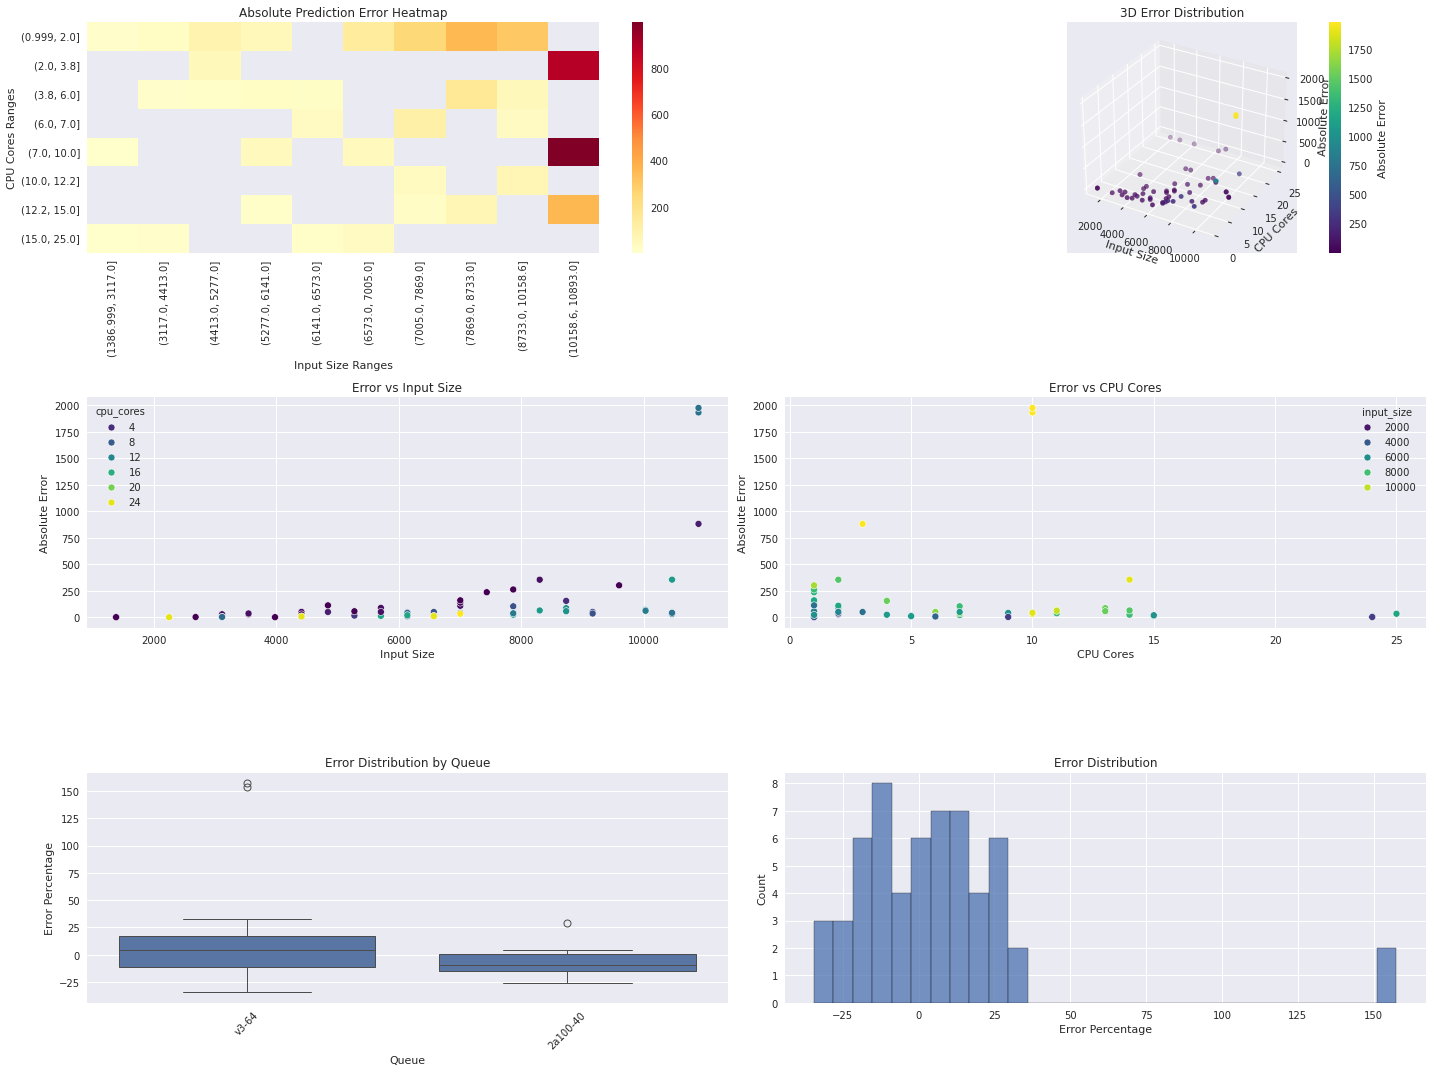


Detailed Error Analysis:

Top 5 Worst Predictions:

Task ID: a474ff57-0185-4e94-b001-dcddd7c1339e
Input Size: 10893
CPU Cores: 10
Queue: v3-64
Actual Time: 3230.98s
Predicted Time: 1254.81s
Absolute Error: 1976.17s
Error Percentage: 157.49%

Task ID: 6b307a08-80a3-47b4-8096-b954ab7d33f1
Input Size: 10893
CPU Cores: 10
Queue: v3-64
Actual Time: 3188.30s
Predicted Time: 1254.81s
Absolute Error: 1933.49s
Error Percentage: 154.09%

Task ID: a811dddc-37e4-4184-81ee-f66b3a86e7f6
Input Size: 10893
CPU Cores: 3
Queue: v3-64
Actual Time: 1747.91s
Predicted Time: 2629.55s
Absolute Error: 881.64s
Error Percentage: -33.53%

Task ID: 70906855-8fb3-4e85-9e13-c1625c843583
Input Size: 10461
CPU Cores: 14
Queue: v3-64
Actual Time: 676.36s
Predicted Time: 1031.59s
Absolute Error: 355.24s
Error Percentage: -34.44%

Task ID: 96110418-b8bf-4130-8126-1f1c27d9c202
Input Size: 8301
CPU Cores: 2
Queue: v3-64
Actual Time: 845.27s
Predicted Time: 1199.85s
Absolute Error: 354.59s
Error Percentage: -29.55%

Error

ValueError: Bin labels must be one fewer than the number of bin edges

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

def analyze_prediction_errors(data_list):
    """分析预测误差与资源配置的关系"""
    
    # 计算每个任务的预测误差
    errors_data = []
    for data in data_list:
        predict_time = predictor._predict_single(data['method'], 
                                              (data['message_sizes.inputs'], 
                                               data['resources.cpu'], 
                                               data['resources.gpu']))
        actual_time = data['time_running']
        error = actual_time - predict_time
        abs_error = abs(error)
        error_percentage = (error / predict_time) * 100 if predict_time != 0 else 0
        
        errors_data.append({
            'task_id': data['task_id'],
            'input_size': data['message_sizes.inputs'],
            'cpu_cores': data['resources.cpu'],
            'queue': data['queue'],
            'actual_time': actual_time,
            'predict_time': predict_time,
            'error': error,
            'abs_error': abs_error,
            'error_percentage': error_percentage
        })
    
    df = pd.DataFrame(errors_data)
    
    # 创建可视化
    plt.style.use('seaborn')
    fig = plt.figure(figsize=(20, 15))
    gs = plt.GridSpec(3, 2)
    
    # 1. 误差热力图
    ax1 = fig.add_subplot(gs[0, 0])
    try:
        # 尝试创建分位数，如果失败则使用等间距分箱
        pivot_table = df.pivot_table(
            values='abs_error',
            index=pd.qcut(df['cpu_cores'], q=10, duplicates='drop'),
            columns=pd.qcut(df['input_size'], q=10, duplicates='drop'),
            aggfunc='mean'
        )
    except ValueError:
        # 如果分位数方法失败，使用等间距分箱
        pivot_table = df.pivot_table(
            values='abs_error',
            index=pd.cut(df['cpu_cores'], bins=10),
            columns=pd.cut(df['input_size'], bins=10),
            aggfunc='mean'
        )
    
    sns.heatmap(pivot_table, cmap='YlOrRd', ax=ax1)
    ax1.set_xlabel('Input Size Ranges')
    ax1.set_ylabel('CPU Cores Ranges')
    ax1.set_title('Absolute Prediction Error Heatmap')
    
    # 2. 3D散点图
    ax2 = fig.add_subplot(gs[0, 1], projection='3d')
    scatter = ax2.scatter(df['input_size'], df['cpu_cores'], df['abs_error'],
                         c=df['abs_error'], cmap='viridis')
    ax2.set_xlabel('Input Size')
    ax2.set_ylabel('CPU Cores')
    ax2.set_zlabel('Absolute Error')
    ax2.set_title('3D Error Distribution')
    plt.colorbar(scatter, ax=ax2, label='Absolute Error')
    
    # 3. 误差与输入大小的关系
    ax3 = fig.add_subplot(gs[1, 0])
    sns.scatterplot(data=df, x='input_size', y='abs_error', hue='cpu_cores',
                   palette='viridis', ax=ax3)
    ax3.set_xlabel('Input Size')
    ax3.set_ylabel('Absolute Error')
    ax3.set_title('Error vs Input Size')
    
    # 4. 误差与CPU核心数的关系
    ax4 = fig.add_subplot(gs[1, 1])
    sns.scatterplot(data=df, x='cpu_cores', y='abs_error', hue='input_size',
                   palette='viridis', ax=ax4)
    ax4.set_xlabel('CPU Cores')
    ax4.set_ylabel('Absolute Error')
    ax4.set_title('Error vs CPU Cores')
    
    # 5. 按队列的误差分布
    ax5 = fig.add_subplot(gs[2, 0])
    sns.boxplot(data=df, x='queue', y='error_percentage', ax=ax5)
    ax5.set_xlabel('Queue')
    ax5.set_ylabel('Error Percentage')
    ax5.set_title('Error Distribution by Queue')
    plt.xticks(rotation=45)
    
    # 6. 误差分布直方图
    ax6 = fig.add_subplot(gs[2, 1])
    sns.histplot(data=df, x='error_percentage', bins=30, ax=ax6)
    ax6.set_xlabel('Error Percentage')
    ax6.set_ylabel('Count')
    ax6.set_title('Error Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # 打印详细分析结果
    print("\nDetailed Error Analysis:")
    
    # 1. 找出误差最大的案例
    worst_predictions = df.nlargest(5, 'abs_error')
    print("\nTop 5 Worst Predictions:")
    for _, row in worst_predictions.iterrows():
        print(f"\nTask ID: {row['task_id']}")
        print(f"Input Size: {row['input_size']}")
        print(f"CPU Cores: {row['cpu_cores']}")
        print(f"Queue: {row['queue']}")
        print(f"Actual Time: {row['actual_time']:.2f}s")
        print(f"Predicted Time: {row['predict_time']:.2f}s")
        print(f"Absolute Error: {row['abs_error']:.2f}s")
        print(f"Error Percentage: {row['error_percentage']:.2f}%")
    
    # 2. 按资源配置分组分析
    print("\nError Analysis by Resource Configuration:")
    
    # 创建资源配置区间（使用 duplicates='drop'）
    df['input_size_bin'] = pd.qcut(df['input_size'], q=5, labels=['Very Small', 'Small', 'Medium', 'Large', 'Very Large'], duplicates='drop')
    df['cpu_bin'] = pd.qcut(df['cpu_cores'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'], duplicates='drop')
    
    group_analysis = df.groupby(['input_size_bin', 'cpu_bin']).agg({
        'abs_error': ['mean', 'std', 'count'],
        'error_percentage': ['mean', 'std']
    }).round(2)
    
    print("\nError Statistics by Resource Groups:")
    print(group_analysis)
    
    # 3. 相关性分析
    print("\nCorrelation Analysis:")
    correlations = df[['input_size', 'cpu_cores', 'abs_error', 'error_percentage']].corr()
    print(correlations['abs_error'].round(3))
    
    # 4. 识别问题区域
    print("\nProblem Areas (configurations with high error rates):")
    problem_threshold = df['error_percentage'].quantile(0.75)
    problem_cases = df[df['error_percentage'] > problem_threshold]
    
    problem_analysis = problem_cases.groupby(['input_size_bin', 'cpu_bin']).size().reset_index(name='count')
    problem_analysis = problem_analysis.sort_values('count', ascending=False)
    print(problem_analysis)
    
    return df

# 使用示例
data = Path("/home/yxx/project/colmena/multisite_/finetuning-surrogates/analysis/test_result/simulation-results.json")
data_list = get_features_from_his_json([data])
error_analysis_df = analyze_prediction_errors(data_list)